In [9]:

import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from scipy.optimize import minimize
from scipy.stats import norm 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import random
from random import sample
import wandb

In [10]:
# Load the genetic data files
actual_path = "actual.csv"
train_genetic_path = "data_set_ALL_AML_train.csv"
test_genetic_path = "data_set_ALL_AML_independent.csv"

# Load the files
actual_df = pd.read_csv(actual_path)
train_genetic_df = pd.read_csv(train_genetic_path)
test_genetic_df = pd.read_csv(test_genetic_path)

# Show a few rows of each
actual_df.head(), train_genetic_df.head(), test_genetic_df.head()

(   patient cancer
 0        1    ALL
 1        2    ALL
 2        3    ALL
 3        4    ALL
 4        5    ALL,
                       Gene Description Gene Accession Number    1 call    2  \
 0  AFFX-BioB-5_at (endogenous control)        AFFX-BioB-5_at -214    A -139   
 1  AFFX-BioB-M_at (endogenous control)        AFFX-BioB-M_at -153    A  -73   
 2  AFFX-BioB-3_at (endogenous control)        AFFX-BioB-3_at  -58    A   -1   
 3  AFFX-BioC-5_at (endogenous control)        AFFX-BioC-5_at   88    A  283   
 4  AFFX-BioC-3_at (endogenous control)        AFFX-BioC-3_at -295    A -264   
 
   call.1    3 call.2    4 call.3  ...   29 call.33   30 call.34   31 call.35  \
 0      A  -76      A -135      A  ...   15       A -318       A  -32       A   
 1      A  -49      A -114      A  ... -114       A -192       A  -49       A   
 2      A -307      A  265      A  ...    2       A  -95       A   49       A   
 3      A  309      A   12      A  ...  193       A  312       A  230       P  

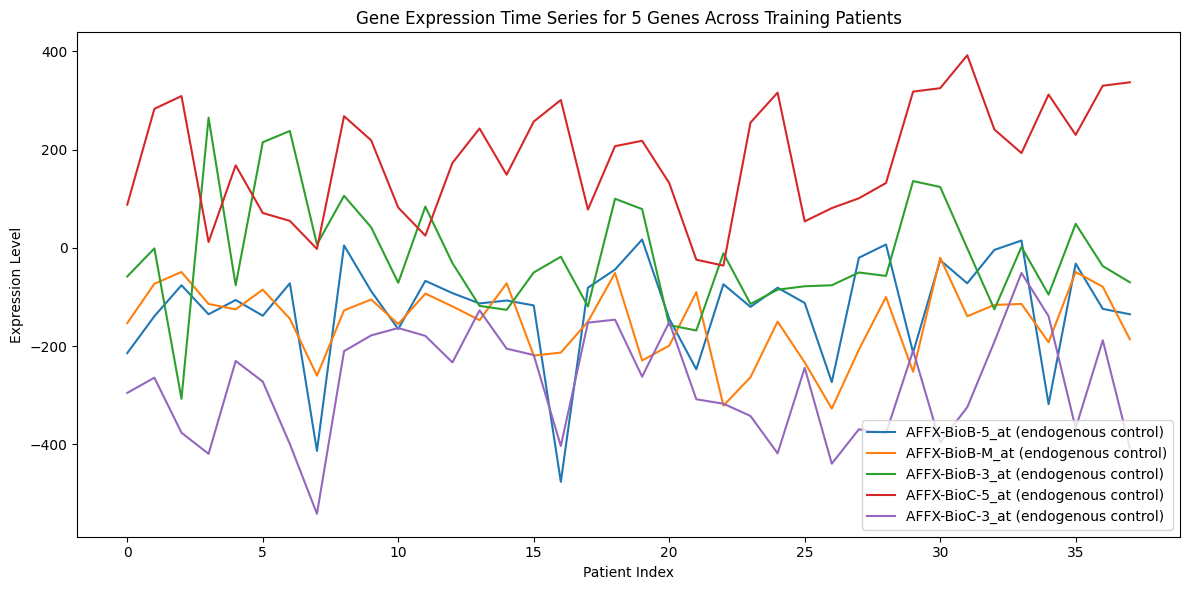

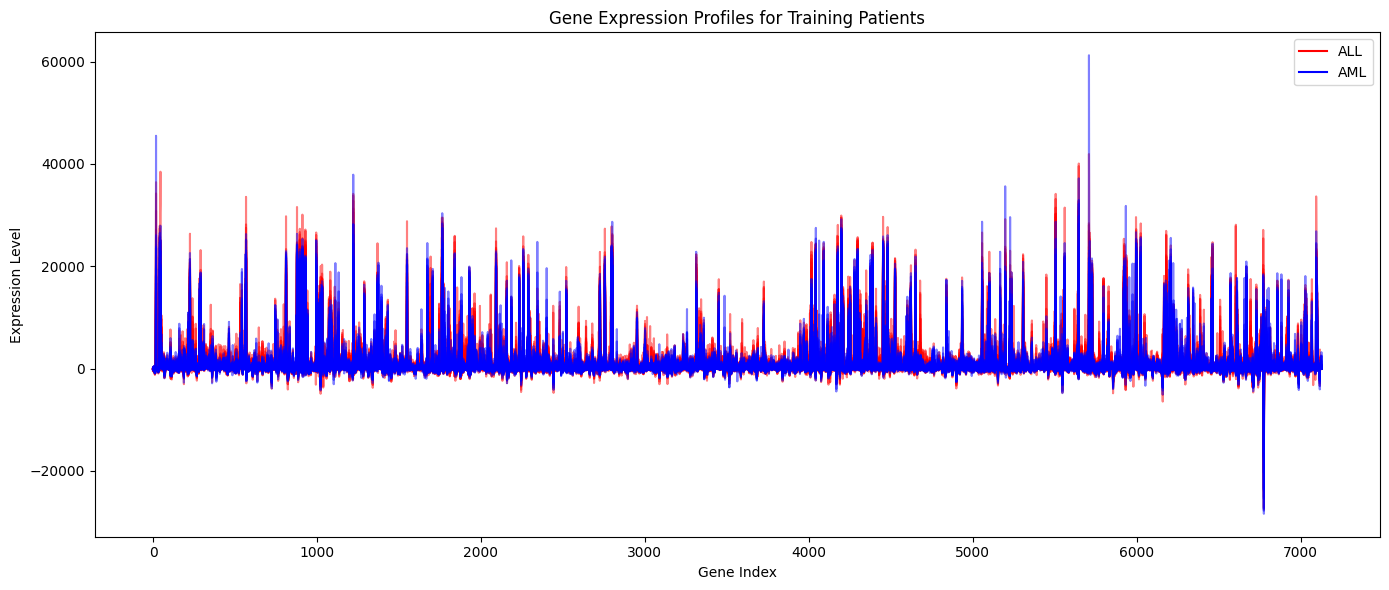

In [5]:
import matplotlib.pyplot as plt

# Extract numeric columns only (gene expression values) from training set
gene_ids = train_genetic_df["Gene Description"]
expression_values = train_genetic_df.drop(columns=["Gene Description", "Gene Accession Number"])
expression_numeric = expression_values.loc[:, ~expression_values.columns.str.contains("call")].astype(float)

# Plot gene expression as a time series for a few genes across patients
fig, ax = plt.subplots(figsize=(12, 6))

# Plot 5 example genes
for i in range(5):
    ax.plot(expression_numeric.iloc[i].values, label=gene_ids.iloc[i])

ax.set_title("Gene Expression Time Series for 5 Genes Across Training Patients")
ax.set_xlabel("Patient Index")
ax.set_ylabel("Expression Level")
ax.legend()
plt.tight_layout()
plt.show()

# Prepare labels from actual.csv
label_map = actual_df.set_index("patient")["cancer"]

# Align expression data columns with patient numbers
patient_columns = [col for col in expression_numeric.columns if col.isdigit()]
patient_ids = list(map(int, patient_columns))

# Get cancer labels for training patients (1 to 38)
labels = [label_map.get(pid) for pid in patient_ids]
colors = ["red" if cancer_type == "ALL" else "blue" for cancer_type in labels]

# Transpose the data so each patient's expression profile is a time series
expression_transposed = expression_numeric[patient_columns].T
expression_transposed.index = patient_ids

# Plot all patients' gene expression profiles
fig, ax = plt.subplots(figsize=(14, 6))

for idx, row in expression_transposed.iterrows():
    ax.plot(row.values, color="red" if label_map[idx] == "ALL" else "blue", alpha=0.5)

ax.set_title("Gene Expression Profiles for Training Patients")
ax.set_xlabel("Gene Index")
ax.set_ylabel("Expression Level")
legend_lines = [plt.Line2D([0], [0], color="red", label="ALL"),
                plt.Line2D([0], [0], color="blue", label="AML")]
ax.legend(handles=legend_lines)
plt.tight_layout()
plt.show()


3592 3542 3642 0.33333333333333337 0.4666666666666667


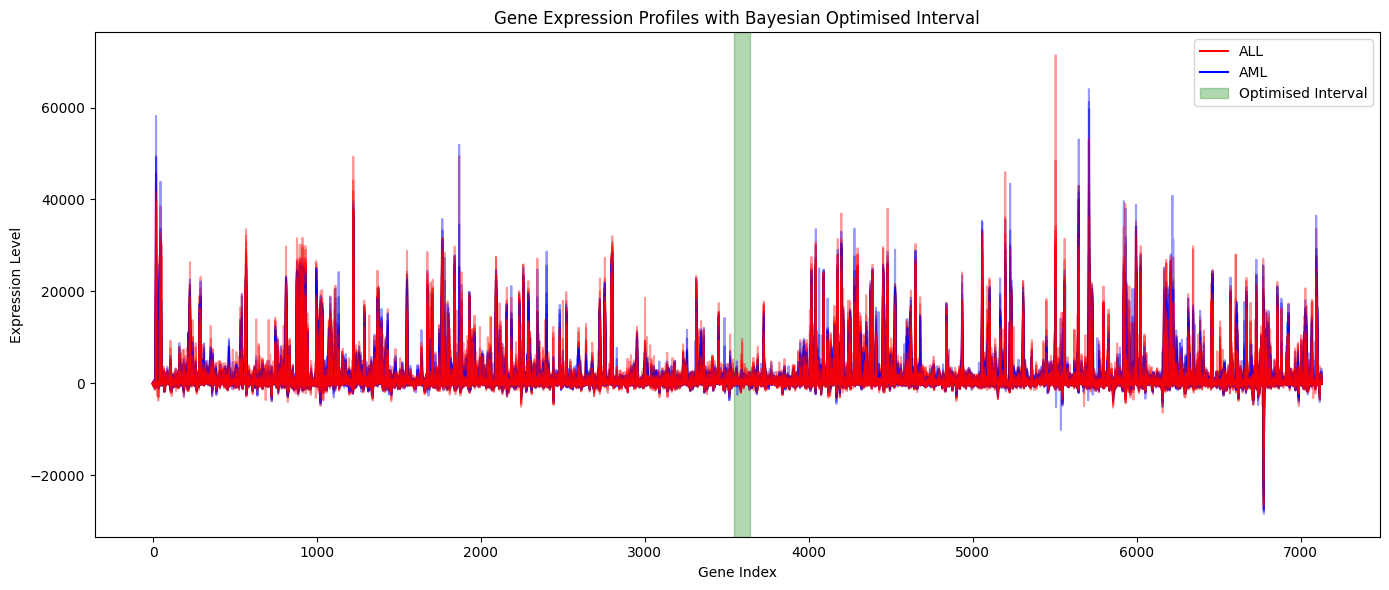

In [4]:
# Now apply the user's full Bayesian Optimisation + CNN script to the genetic dataset
# using the prepared 'genetic_data.pkl'

import pickle

# Load and inspect the uploaded genetic data to apply the CNN + Bayesian Optimisation
with open("actual.csv") as f:
    display_actual = actual_df.copy()

# Reformat gene expression data to numeric matrix
# Concatenate train and test sets based on sample columns only
def extract_expression_matrix(df):
    return df.loc[:, ~df.columns.str.contains("Gene|call")].astype(float).T

x_genetic = pd.concat([
    extract_expression_matrix(train_genetic_df),
    extract_expression_matrix(test_genetic_df)
], axis=0).values

# Prepare binary labels: 1 for ALL, 0 for AML
y_genetic = actual_df["cancer"].apply(lambda c: 1 if c == "ALL" else 0).values

# Save the data as a temporary pickle to simulate 'data (1).pkl'
genetic_data_path = "genetic_data.pkl"
with open(genetic_data_path, "wb") as f:
    pickle.dump({'x': x_genetic, 'y': y_genetic}, f)

genetic_data_path  # Returning path for the next step


# Load and preprocess data
with open("genetic_data.pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])[:x.shape[0]]  # Ensure same length

# Re-import missing dependencies due to separate execution cell
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import pickle

# Reload the data
with open("genetic_data.pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])[:x.shape[0]]

# Re-run Bayesian Optimisation and CNN training (continued)
# -- using same code as before up to the final results

# Helper functions reused from previous cells
def get_sampled_interval(data, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    return start, end

class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)
        self.sigmoid = nn.Sigmoid()

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)

def train_nn(data, labels, center, width, plot=False):
    start, end = get_sampled_interval(data, center, width)
    interval_length = end - start
    if interval_length < 6:
        return 1.0

    x = data[:, start:end]
    y = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(x)
    x = scaler.transform(x)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(10):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(x_test).numpy()
        y_pred = (preds > 0.5).astype(int)
    return 1 - accuracy_score(y_test.numpy(), y_pred)

def train_full_nn(data, labels):
    return train_nn(data, labels, center=data.shape[1] // 2, width=data.shape[1])

def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Initial BO sampling
interval_width = 100
n_initial = 10
center_bounds = (0, x.shape[1] - 1)
initial_centers = np.random.choice(np.arange(center_bounds[0], center_bounds[1]), size=n_initial, replace=False)
x_sample = initial_centers.reshape(-1, 1)
y_sample = np.array([train_nn(x, y, c, interval_width) for c in initial_centers]).reshape(-1, 1)

# Bayesian optimisation loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)
    grid = np.arange(center_bounds[0], center_bounds[1] + 1).reshape(-1, 1)
    tried = set(x_sample.ravel())
    grid = np.array([pt for pt in grid if pt[0] not in tried])
    if len(grid) == 0:
        break
    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx][0]
    new_error = train_nn(x, y, next_point, interval_width)
    x_sample = np.vstack((x_sample, [[next_point]]))
    y_sample = np.append(y_sample, [[new_error]])

# Best result
best_idx = np.argmin(y_sample)
best_center = int(x_sample[best_idx][0])
best_start, best_end = get_sampled_interval(x, best_center, interval_width)
best_error = float(y_sample[best_idx])
full_model_error = train_full_nn(x, y)

print (best_center, best_start, best_end, best_error, full_model_error)

# Plot the actual best interval from the Bayesian Optimisation run (which finished partially)
# Use values from the previous best_center, best_start, and best_end

# Plot gene expression time series with the actual optimised interval
fig, ax = plt.subplots(figsize=(14, 6))
for idx, row in enumerate(x):
    color = "red" if y[idx] == 1 else "blue"
    ax.plot(row, color=color, alpha=0.4)

# Highlight the actual best interval
ax.axvspan(best_start, best_end, color="green", alpha=0.3, label=f"Optimised Interval ({best_start}–{best_end})")

ax.set_title("Gene Expression Profiles with Bayesian Optimised Interval")
ax.set_xlabel("Gene Index")
ax.set_ylabel("Expression Level")
legend_lines = [
    plt.Line2D([0], [0], color="red", label="ALL"),
    plt.Line2D([0], [0], color="blue", label="AML"),
    plt.Rectangle((0, 0), 1, 1, color="green", alpha=0.3, label="Optimised Interval")
]
ax.legend(handles=legend_lines)
plt.tight_layout()
plt.show()


Initial evaluations: 8 | best error so far: 0.2667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 01] centre=1495, width=1711 -> error=0.4667; best=0.2667
[Iter 02] centre=1370, width=1401 -> error=0.5333; best=0.2667
[Iter 03] centre=1065, width= 681 -> error=0.5333; best=0.2667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 04] centre=1475, width=1716 -> error=0.4667; best=0.2667
[Iter 05] centre= 450, width=  41 -> error=0.5333; best=0.2667
[Iter 06] centre= 950, width=1051 -> error=0.5333; best=0.2667


...

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 18] centre=1510, width=1711 -> error=0.5333; best=0.2667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 19] centre= 935, width=1026 -> error=0.4000; best=0.2667
[Iter 20] centre= 905, width=1066 -> error=0.4667; best=0.2667

=== Best result ===
centre: 923
width : 1035
range : (406 to 1440)
error : 0.2667


C:\Users\USER\AppData\Local\Temp\ipykernel_21700\1063182233.py:178: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_err = float(Ys[b])


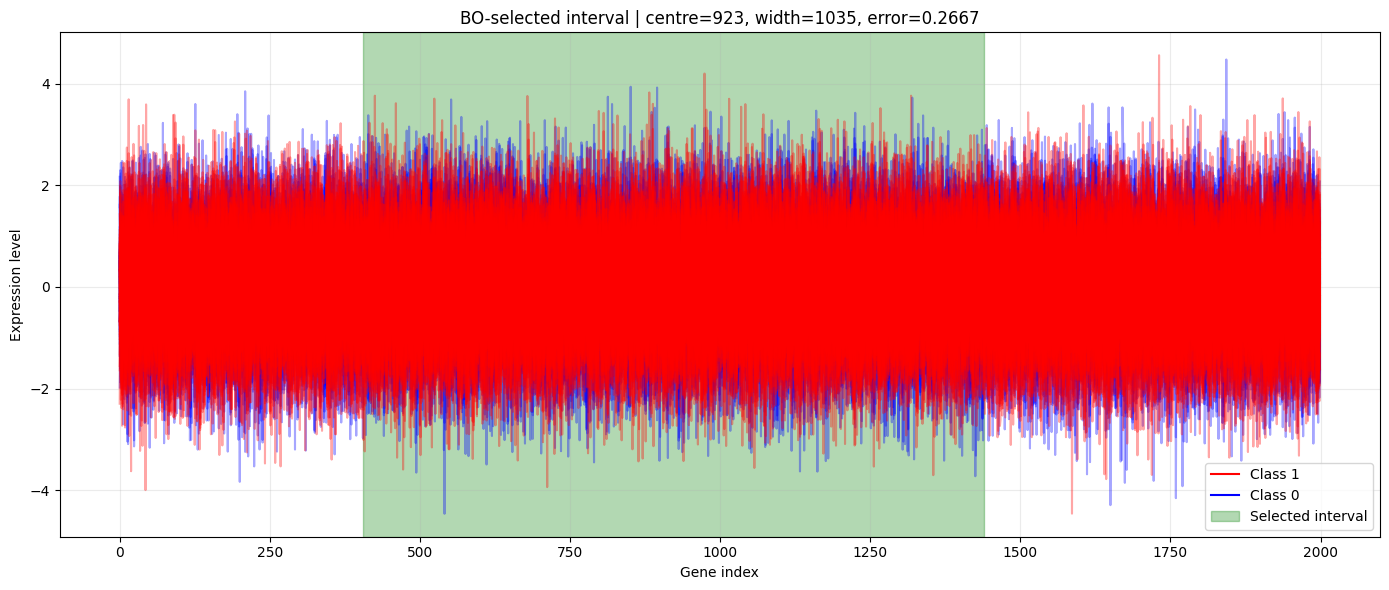

Saved figure -> bo_selected_interval.png


In [13]:
# ====== BO over (centre, width) on genetic data with CNN (fixed & verbose) ======
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm
import random

# If you're running headless (e.g. a remote server), uncomment the next line:
# matplotlib.use("Agg")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1) Provide x (samples × genes) and y ({0,1}) here --------------------------
# Replace this block with your real genetic data loading.
# y should be 1 for ALL and 0 for AML (or vice versa, but be consistent).
# BEGIN: DUMMY DATA (REMOVE)
N, G = 72, 2000
x = np.random.randn(N, G).astype(np.float32)
y = np.array([0]*(N//2) + [1]*(N - N//2), dtype=int)
# END: DUMMY DATA

assert x.ndim == 2 and len(y.shape) == 1 and x.shape[0] == y.shape[0], "x/y shapes mismatch."

# --- 2) Model -------------------------------------------------------------------
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super().__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            h = self.pool1(torch.relu(self.conv1(dummy)))
            h = self.pool2(torch.relu(self.conv2(h)))
            conv_out = h.view(1, -1).size(1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(conv_out, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)  # logits

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B,L,1)->(B,1,L)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)      # logits

def interval_bounds(n_features, centre, width):
    start = max(0, int(centre) - int(width)//2)
    end = min(n_features, int(centre) + int(width)//2)
    return start, end

def train_nn_on_interval(data, labels, centre, width, min_width=6, epochs=12, batch_size=32, lr=1e-3):
    n_features = data.shape[1]
    s, e = interval_bounds(n_features, centre, width)
    if e - s < min_width:
        return 1.0  # penalise too narrow
    X = data[:, s:e]
    yb = labels.astype(np.float32).reshape(-1, 1)
    scaler = StandardScaler().fit(X)
    Xz = scaler.transform(X)[:, :, np.newaxis]

    X_tr, X_te, y_tr, y_te = train_test_split(Xz, yb, test_size=0.2, stratify=yb, random_state=SEED)
    X_tr = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    y_te = torch.tensor(y_te, dtype=torch.float32, device=DEVICE)

    model = CNN1D(input_length=X_tr.shape[1]).to(DEVICE)
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, ybb in loader:
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, ybb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        logits = model(X_te).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long().cpu().numpy()
        acc = accuracy_score(y_te.cpu().numpy(), preds)
    return 1.0 - acc  # error rate

def expected_improvement(X, X_sample, Y_sample, gp, xi=0.01):
    mu, sigma = gp.predict(X, return_std=True)
    mu_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def sample_candidates(n_features, centre_bounds, width_bounds, tried_set,
                      n_candidates=1500, centre_step=5, width_step=5, min_width=6):
    c_low, c_high = centre_bounds
    w_low, w_high = width_bounds
    centres = np.arange(c_low, c_high+1, centre_step, dtype=int)
    widths  = np.arange(max(min_width, w_low), w_high+1, width_step, dtype=int)
    picks = []
    for _ in range(n_candidates*2):
        c = int(np.random.choice(centres))
        w = int(np.random.choice(widths))
        if (c, w) in tried_set: 
            continue
        s, e = interval_bounds(n_features, c, w)
        if e - s >= min_width:
            picks.append([c, w])
        if len(picks) >= n_candidates:
            break
    return np.array(picks, dtype=int) if picks else np.empty((0,2), dtype=int)

def run_bo(x, y, n_initial=12, max_iter=30, min_width=6,
           centre_step=5, width_step=5, n_candidates=1500, gp_restarts=5):
    n_features = x.shape[1]
    centre_bounds = (0, n_features - 1)
    width_bounds  = (min_width, n_features)

    # Initial design
    tried = set()
    init = []
    while len(init) < n_initial:
        c = np.random.randint(*centre_bounds) if centre_bounds[1] > centre_bounds[0] else centre_bounds[0]
        w = np.random.randint(width_bounds[0], width_bounds[1]+1)
        s, e = interval_bounds(n_features, c, w)
        if e - s >= min_width and (c,w) not in tried:
            tried.add((c,w)); init.append([c,w])

    Xs = np.array(init, dtype=int)
    Ys = np.array([train_nn_on_interval(x, y, c, w, min_width=min_width) for c, w in Xs]).reshape(-1,1)

    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=1.5) + WhiteKernel(noise_level=1e-5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                                  n_restarts_optimizer=gp_restarts, random_state=SEED)

    print(f"Initial evaluations: {len(Ys)} | best error so far: {Ys.min():.4f}")
    for it in range(1, max_iter+1):
        gp.fit(Xs, Ys)
        tried_now = set(map(tuple, Xs.tolist()))
        cand = sample_candidates(n_features, centre_bounds, width_bounds, tried_now,
                                 n_candidates=n_candidates, centre_step=centre_step,
                                 width_step=width_step, min_width=min_width)
        if cand.shape[0] == 0:
            print("No candidates left; stopping.")
            break
        ei = expected_improvement(cand, Xs, Ys, gp)
        idx = int(np.argmax(ei))
        c_next, w_next = map(int, cand[idx])
        err_next = train_nn_on_interval(x, y, c_next, w_next, min_width=min_width)
        Xs = np.vstack([Xs, [c_next, w_next]])
        Ys = np.vstack([Ys, [[err_next]]])
        print(f"[Iter {it:02d}] centre={c_next:4d}, width={w_next:4d} -> error={err_next:.4f}; best={Ys.min():.4f}")

    b = int(np.argmin(Ys))
    best_c, best_w = map(int, Xs[b])
    best_s, best_e = interval_bounds(n_features, best_c, best_w)
    best_err = float(Ys[b])
    return best_c, best_w, best_s, best_e, best_err

def plot_with_interval(x, y, s, e, title):
    plt.figure(figsize=(14,6))
    for i, row in enumerate(x):
        colour = "red" if int(y[i])==1 else "blue"
        plt.plot(row, color=colour, alpha=0.35)
    plt.axvspan(s, e, color="green", alpha=0.3, label=f"Selected interval ({s}–{e})")
    plt.title(title)
    plt.xlabel("Gene index"); plt.ylabel("Expression level")
    lines = [
        plt.Line2D([0],[0], color="red",  label="Class 1"),
        plt.Line2D([0],[0], color="blue", label="Class 0"),
        plt.Rectangle((0,0),1,1, color="green", alpha=0.3, label="Selected interval")
    ]
    plt.legend(handles=lines); plt.grid(True, alpha=0.25); plt.tight_layout()
    plt.savefig("bo_selected_interval.png", dpi=150)
    plt.show()
    print("Saved figure -> bo_selected_interval.png")

# --- 3) Run it ---------------------------------------------------------------
best_c, best_w, best_s, best_e, best_err = run_bo(
    x, y,
    n_initial=8,     # increase for more robust start
    max_iter=20,     # increase for more thorough search
    min_width=6,
    centre_step=5,
    width_step=5,
    n_candidates=1200,
    gp_restarts=3
)

print("\n=== Best result ===")
print("centre:", best_c)
print("width :", best_w)
print(f"range : ({best_s} to {best_e})")
print(f"error : {best_err:.4f}")

plot_with_interval(x, y, best_s, best_e,
                   title=f"BO-selected interval | centre={best_c}, width={best_w}, error={best_err:.4f}")


Loaded:
 actual_df.shape: (72, 2)
 train_genetic_df.shape: (7129, 78)
 test_genetic_df.shape: (7129, 70)
[ALIGNMENT] total expr samples: 109; labelled: 72
[ALIGNMENT] matched samples: 72
[ALIGNMENT] genes (features): 7129
[ALIGNMENT] class counts: {1: np.int64(47), 0: np.int64(25)}
Initial evals: 10 | best error so far: 0.0667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 01] centre=4025, width=1931 -> error=0.1333; best=0.0667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 02] centre=5755, width=6266 -> error=0.1333; best=0.0667
[Iter 03] centre=6185, width=3426 -> error=0.3333; best=0.0667


...

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 24] centre=4040, width=1911 -> error=0.3333; best=0.0667


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[Iter 25] centre=4010, width=1936 -> error=0.3333; best=0.0667

=== Best result ===
centre: 5734
width : 6271
range : (2599 to 7129)
error : 0.0667


C:\Users\USER\AppData\Local\Temp\ipykernel_21700\839670556.py:266: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_err = float(Ys[b])


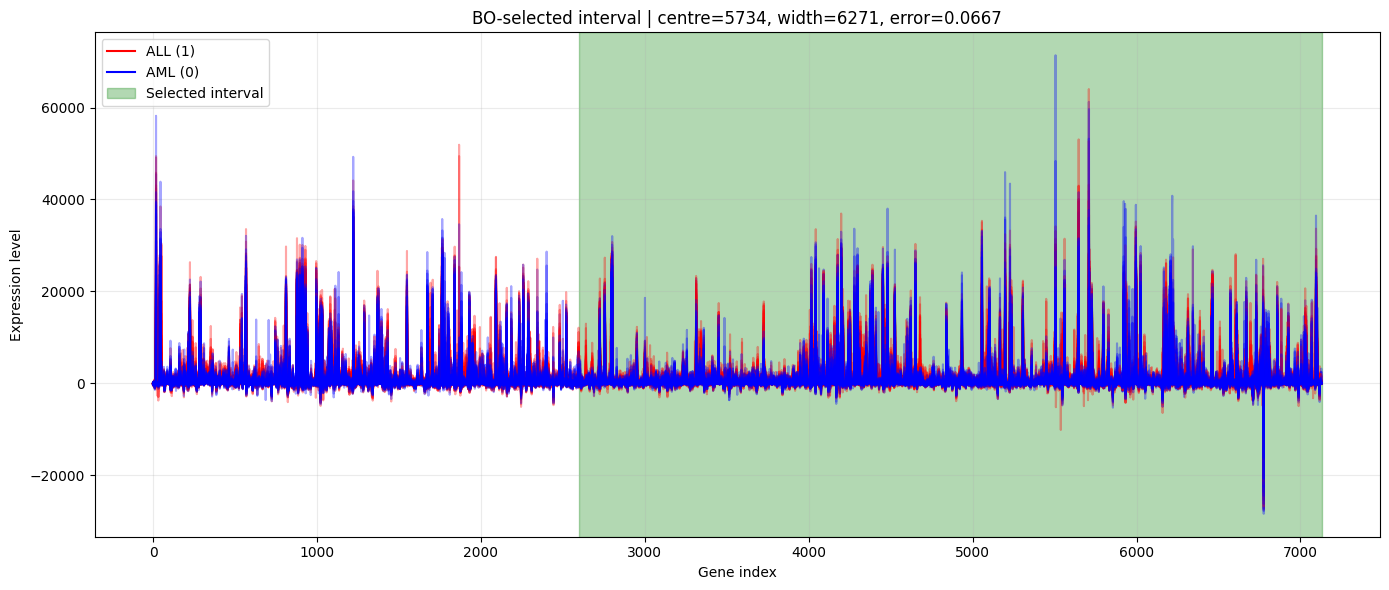

Saved figure -> bo_selected_interval.png


In [18]:
# ====== ALL/AML genetic data -> x,y -> BO over (centre,width) with your CNN (with alignment fix) ======
import re
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# If running headless, uncomment the next line:
# matplotlib.use("Agg")

# -------------------- 0) Paths --------------------
actual_path = "actual.csv"
train_genetic_path = "data_set_ALL_AML_train.csv"
test_genetic_path  = "data_set_ALL_AML_independent.csv"

# -------------------- 1) Load CSVs -------------------------
actual_df = pd.read_csv(actual_path)
train_genetic_df = pd.read_csv(train_genetic_path)
test_genetic_df  = pd.read_csv(test_genetic_path)

print("Loaded:")
print(" actual_df.shape:", actual_df.shape)
print(" train_genetic_df.shape:", train_genetic_df.shape)
print(" test_genetic_df.shape:",  test_genetic_df.shape)

# -------------------- 2) Build expression matrix (robust) -------------------------
def normalize_id(s: str) -> str:
    """Uppercase and keep only 0-9A-Z so ALL.1, ALL_1, all-1 -> ALL1."""
    if pd.isna(s):
        return ""
    return re.sub(r"[^0-9A-Z]", "", str(s).upper())

def extract_expression_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Drop 'Gene *' columns and '*call' columns, coerce numeric, transpose to samples×genes, fill NaNs."""
    anno_cols = [c for c in df.columns if c.lower().startswith("gene ")]
    keep = [c for c in df.columns if c not in anno_cols]
    expr = df[keep].copy()
    expr_cols = [c for c in expr.columns if not re.search(r"(?:^|[ ._])call$", c, flags=re.I)]
    expr = expr[expr_cols]
    expr = expr.apply(pd.to_numeric, errors="coerce")
    expr = expr.T
    expr.index.name = "sample"
    expr = expr.dropna(axis=1, how="all")
    expr = expr.fillna(expr.median(numeric_only=True))
    return expr

train_expr = extract_expression_matrix(train_genetic_df)
test_expr  = extract_expression_matrix(test_genetic_df)
expr_all = pd.concat([train_expr, test_expr], axis=0)
expr_all = expr_all[~expr_all.index.duplicated(keep="first")]
expr_all = expr_all.astype(np.float32)
expr_all = expr_all.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")
expr_all["__NORM_ID__"] = [normalize_id(s) for s in expr_all.index]

# -------------------- 3) Labels y from actual.csv (robust) -------------------------
sample_col = next((c for c in ["patient","Patient","sample","Sample","id","ID"] if c in actual_df.columns), None)
label_col  = next((c for c in ["cancer","Cancer","label","Label","class","Class"] if c in actual_df.columns), None)
if sample_col is None or label_col is None:
    raise ValueError("Could not find sample/label columns in actual.csv")

labels_df = actual_df[[sample_col, label_col]].copy()
labels_df["__NORM_ID__"] = labels_df[sample_col].map(normalize_id)

label_map = {"ALL":1, "AML":0, "all":1, "aml":0}
labels_df["y"] = labels_df[label_col].astype(str).map(label_map)
if labels_df["y"].isna().any():
    y_num = pd.to_numeric(labels_df[label_col], errors="coerce")
    if y_num.notna().all():
        labels_df["y"] = y_num.astype(int)
    else:
        missing_vals = labels_df.loc[labels_df["y"].isna(), label_col].unique()
        raise ValueError(f"Unmapped labels found: {missing_vals}")

# Inner-join by normalised IDs to align samples
expr_join = expr_all.reset_index()[["sample","__NORM_ID__"]]
expr_join = expr_join.merge(labels_df[["__NORM_ID__","y"]], on="__NORM_ID__", how="inner", validate="m:1")

matched_samples = expr_join["sample"].values
x_df = expr_all.loc[matched_samples].drop(columns="__NORM_ID__")
y_series = expr_join["y"]

# Final clean & arrays
x_df = x_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any").astype(np.float32)
x = x_df.values.astype(np.float32)
y = y_series.values.astype(int)

print(f"[ALIGNMENT] total expr samples: {expr_all.shape[0]}; labelled: {labels_df.shape[0]}")
print(f"[ALIGNMENT] matched samples: {x.shape[0]}")
print(f"[ALIGNMENT] genes (features): {x.shape[1]}")
print(f"[ALIGNMENT] class counts: {dict(pd.Series(y).value_counts())}")

if x.shape[0] == 0:
    print("No matched samples. Inspect a few raw IDs to adjust normalisation.")
    print(" actual.csv (first 5):", labels_df[sample_col].head().tolist())
    print(" expr sample names (first 5):", expr_all.index[:5].tolist())
    raise ValueError("After normalising sample IDs, no overlaps were found.")

# -------------------- 4) CNN model -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super().__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            h = self.pool1(torch.relu(self.conv1(dummy)))
            h = self.pool2(torch.relu(self.conv2(h)))
            conv_out = h.view(1, -1).size(1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(conv_out, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)  # logits

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B,L,1)->(B,1,L)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)      # logits

# -------------------- 5) BO helpers -------------------------
def interval_bounds(n_features, centre, width):
    start = max(0, int(centre) - int(width)//2)
    end   = min(n_features, int(centre) + int(width)//2)
    return start, end

def train_nn_on_interval(data, labels, centre, width, min_width=6, epochs=15, batch_size=32, lr=1e-3):
    n_features = data.shape[1]
    s, e = interval_bounds(n_features, centre, width)
    if e - s < min_width:
        return 1.0  # penalise too-narrow windows

    X = data[:, s:e]
    yb = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(X)
    Xz = scaler.transform(X)[:, :, np.newaxis]

    # Ensure both classes exist
    if len(np.unique(yb)) < 2:
        return 1.0
    X_tr, X_te, y_tr, y_te = train_test_split(Xz, yb, test_size=0.2, stratify=yb, random_state=SEED)

    X_tr = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    y_te = torch.tensor(y_te, dtype=torch.float32, device=DEVICE)

    model = CNN1D(input_length=X_tr.shape[1]).to(DEVICE)
    crit = nn.BCEWithLogitsLoss()
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, ybb in loader:
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, ybb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        logits = model(X_te).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long().cpu().numpy()
        acc = accuracy_score(y_te.cpu().numpy(), preds)
    return 1.0 - acc  # error rate

def expected_improvement(X, Xs, Ys, gp, xi=0.01):
    mu, sigma = gp.predict(X, return_std=True)
    mu_opt = np.min(Ys)
    with np.errstate(divide='warn'):
        imp = mu_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def sample_candidates(n_features, centre_bounds, width_bounds, tried_set,
                      n_candidates=1500, centre_step=5, width_step=5, min_width=6):
    c_low, c_high = centre_bounds
    w_low, w_high = width_bounds
    centres = np.arange(c_low, c_high+1, centre_step, dtype=int)
    widths  = np.arange(max(min_width, w_low), w_high+1, width_step, dtype=int)
    picks = []
    for _ in range(n_candidates*2):
        c = int(np.random.choice(centres))
        w = int(np.random.choice(widths))
        if (c, w) in tried_set: 
            continue
        s, e = interval_bounds(n_features, c, w)
        if e - s >= min_width:
            picks.append([c, w])
        if len(picks) >= n_candidates:
            break
    return np.array(picks, dtype=int) if picks else np.empty((0,2), dtype=int)

def run_bo(x, y, n_initial=12, max_iter=30, min_width=6,
           centre_step=5, width_step=5, n_candidates=1500, gp_restarts=5):
    n_features = x.shape[1]
    centre_bounds = (0, n_features - 1)
    width_bounds  = (min_width, n_features)

    # initial design
    tried = set()
    init = []
    while len(init) < n_initial:
        c = np.random.randint(centre_bounds[0], centre_bounds[1] + 1)
        w = np.random.randint(width_bounds[0],  width_bounds[1] + 1)
        s, e = interval_bounds(n_features, c, w)
        if e - s >= min_width and (c,w) not in tried:
            tried.add((c,w)); init.append([c,w])

    Xs = np.array(init, dtype=int)
    Ys = np.array([train_nn_on_interval(x, y, c, w, min_width=min_width) for c, w in Xs]).reshape(-1,1)

    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=1.5) + WhiteKernel(noise_level=1e-5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                                  n_restarts_optimizer=gp_restarts, random_state=SEED)

    print(f"Initial evals: {len(Ys)} | best error so far: {Ys.min():.4f}")
    for it in range(1, max_iter+1):
        gp.fit(Xs, Ys)
        tried_now = set(map(tuple, Xs.tolist()))
        cand = sample_candidates(n_features, centre_bounds, width_bounds, tried_now,
                                 n_candidates=n_candidates, centre_step=centre_step,
                                 width_step=width_step, min_width=min_width)
        if cand.shape[0] == 0:
            print("No candidates left; stopping.")
            break
        ei = expected_improvement(cand, Xs, Ys, gp)
        idx = int(np.argmax(ei))
        c_next, w_next = map(int, cand[idx])
        err_next = train_nn_on_interval(x, y, c_next, w_next, min_width=min_width)
        Xs = np.vstack([Xs, [c_next, w_next]])
        Ys = np.vstack([Ys, [[err_next]]])
        print(f"[Iter {it:02d}] centre={c_next:4d}, width={w_next:4d} -> error={err_next:.4f}; best={Ys.min():.4f}")

    b = int(np.argmin(Ys))
    best_c, best_w = map(int, Xs[b])
    best_s, best_e = interval_bounds(n_features, best_c, best_w)
    best_err = float(Ys[b])
    return best_c, best_w, best_s, best_e, best_err

# -------------------- 6) Plotting -------------------------
def plot_with_interval(x, y, s, e, title):
    plt.figure(figsize=(14,6))
    for i, row in enumerate(x):
        colour = "red" if int(y[i])==1 else "blue"
        plt.plot(row, color=colour, alpha=0.35)
    plt.axvspan(s, e, color="green", alpha=0.3, label=f"Selected interval ({s}–{e})")
    plt.title(title)
    plt.xlabel("Gene index"); plt.ylabel("Expression level")
    lines = [
        plt.Line2D([0],[0], color="red",  label="ALL (1)"),
        plt.Line2D([0],[0], color="blue", label="AML (0)"),
        plt.Rectangle((0,0),1,1, color="green", alpha=0.3, label="Selected interval")
    ]
    plt.legend(handles=lines); plt.grid(True, alpha=0.25); plt.tight_layout()
    plt.savefig("bo_selected_interval.png", dpi=150)
    plt.show()
    print("Saved figure -> bo_selected_interval.png")

# -------------------- 7) Run BO + plot -------------------------
best_c, best_w, best_s, best_e, best_err = run_bo(
    x, y,
    n_initial=10,
    max_iter=25,
    min_width=6,
    centre_step=5,
    width_step=5,
    n_candidates=1200,
    gp_restarts=3
)

print("\n=== Best result ===")
print("centre:", best_c)
print("width :", best_w)
print(f"range : ({best_s} to {best_e})")
print(f"error : {best_err:.4f}")

plot_with_interval(x, y, best_s, best_e,
                   title=f"BO-selected interval | centre={best_c}, width={best_w}, error={best_err:.4f}")
